<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/Diabetics_Prediction_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/SkillMorph Datasets/diabetes_prediction_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
import os

# List contents of the directory where the file is expected
!ls '/content/drive/MyDrive/SkillMorph Datasets/'

 cybersecurity_intrusion_data.csv    Housing.csv
'dataset_with_all_features v2.csv'   PGCB_BD.xlsx
 diabetes.csv			     roc_auc_curve.png
 diabetes_prediction_dataset.csv     StudentDepressionDataset.csv
 gym_membership.csv		     StudentsPerformance.csv
 heart.csv


In [7]:
# Drop rows with missing values
df.dropna(inplace=True)

# Encode categorical features
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Remove near-constant (near-zero-variance) columns.
# Every record here is a student, so 'Work Pressure', 'Job Satisfaction'
# and 'Profession' are ~constant (one value in >99% of rows). After scaling,
# their rare non-zero rows become extreme outliers that dominate GaussianNB's
# per-feature likelihoods and collapse its predictions to a single class.
near_constant = [c for c in df.columns
                 if c != 'Depression'
                 and df[c].value_counts(normalize=True).iloc[0] > 0.99]
print('Dropping near-constant columns:', near_constant)
df.drop(columns=near_constant, inplace=True)

Dropping near-constant columns: []


In [9]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (80000, 8) | Test: (20000, 8)


In [10]:
# SVM (RBF kernel with probability estimates for ROC)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print('Training complete.')

Training complete.


In [13]:
print('='*55)
print('SVM Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_svm, digits=4,
      target_names=['Diabetes', 'No Diabetes']))

print('='*55)
print('Naive Bayes Classification Report')
print('='*55)
print(classification_report(y_test, y_pred_nb, digits=4,
      target_names=['Diabetes', 'No Diabetes']))

SVM Classification Report
              precision    recall  f1-score   support

    Diabetes     0.9641    0.9984    0.9809     18300
 No Diabetes     0.9723    0.5994    0.7416      1700

    accuracy                         0.9645     20000
   macro avg     0.9682    0.7989    0.8613     20000
weighted avg     0.9648    0.9645    0.9606     20000

Naive Bayes Classification Report
              precision    recall  f1-score   support

    Diabetes     0.9670    0.9273    0.9467     18300
 No Diabetes     0.4574    0.6594    0.5401      1700

    accuracy                         0.9045     20000
   macro avg     0.7122    0.7934    0.7434     20000
weighted avg     0.9237    0.9045    0.9122     20000



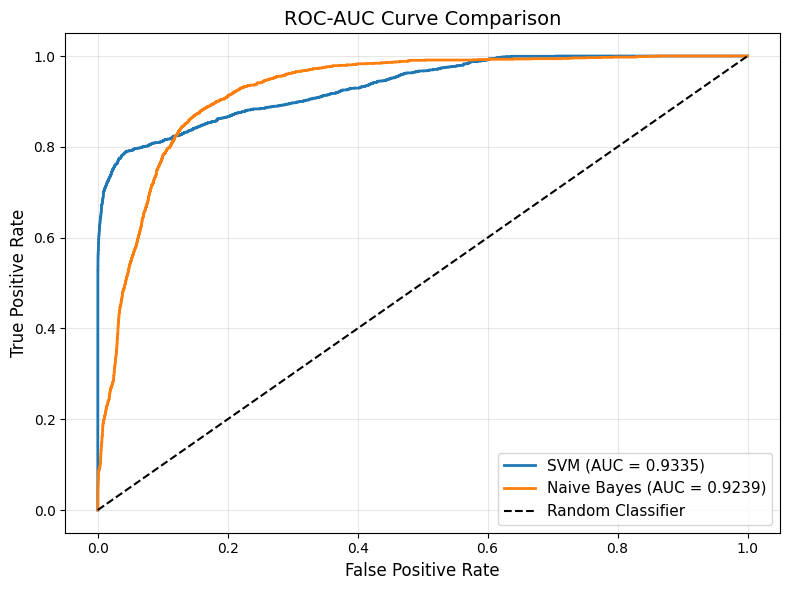

In [14]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SkillMorph Datasets/roc_auc_curve.png', dpi=600)
plt.show()

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    'Model': ['SVM (RBF)', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_nb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_nb)
    ],
    'ROC-AUC': [auc_svm, auc_nb]
})

# Format to 4 decimal places
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)
results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.9645,0.9723,0.5994,0.7416,0.9335
1,Naive Bayes,0.9046,0.4574,0.6594,0.5401,0.9239
